<a href="https://colab.research.google.com/github/badaozhiwei-cmyk/zero-to-herp/blob/main/build_makemore_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [44]:
# download the names.txt file from github
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

--2026-03-12 13:29:18--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt.2’

names.txt.2         100%[===================>] 222.80K  --.-KB/s    in 0.09s   

2026-03-12 13:29:18 (2.36 MB/s) - ‘names.txt.2’ saved [228145/228145]



In [45]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [46]:
len(words)

32033

In [47]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [69]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  for w in words:
  #因为名字长度不一，三个输入一个输出会带来不同的样本集
    print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

流式输出内容被截断，只能显示最后 5000 行内容。
marvelous
araiya
kamyah
nahim
myson
ngawang
obryan
abbigail
ezana
mykaela
farzan
celeste
rhiannon
omeir
aryani
joscelyn
avrielle
angellina
lawsyn
khristian
irma
swar
felicie
makensie
eternity
llewellyn
mayvis
dayan
alisia
alicja
joseluis
maysoon
deion
krista
noora
binti
xion
amarie
kaura
erik
kawthar
kristy
karah
davonna
darrion
kelly
samarah
arijah
briggston
memphis
ridger
parris
raffaella
bexleigh
donya
lunah
kc
nollan
adin
tziry
norris
elias
jeyla
shiro
emmalynne
marcoantonio
kacee
lenix
miciah
shehab
autry
jeryn
jolani
bellarose
kacelyn
dakarai
theadore
osmani
tamim
mani
nalanii
remley
ilian
lucky
winsley
glori
grayce
kris
lovette
hadriel
selah
cub
emanuele
dasan
emberlie
oaklynd
thaliah
winner
emauri
jayce
nahiara
hyde
giorgio
allissa
lonan
janhvi
kynlee
xinyu
maximo
melanee
anqi
jonel
dayne
azadeh
jaylyn
nasirah
kutter
khori
antoinette
tysin
kani
aden
mikaal
arlyne
dyani
xayah
huzaifa
leiyani
brayla
curt
nunzio
shyann
juliette
adonijah
jazalynn
chinyere

In [70]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
#词嵌入矩阵
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [71]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [72]:
for p in parameters:
  p.requires_grad = True

In [73]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [74]:
lri = []
lossi = []
stepi = []

In [84]:
for i in range(200000):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))

  #forward pass
  #Xtr[ix] (一个批次的数据)，它的形状是 (batch_size, block_size)，(32, 3)。
  #执行emb=C[Xtr[ix]]时，模型会为这32个样本中的每一个，取出其3个上下文字符对应的嵌入向量。
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

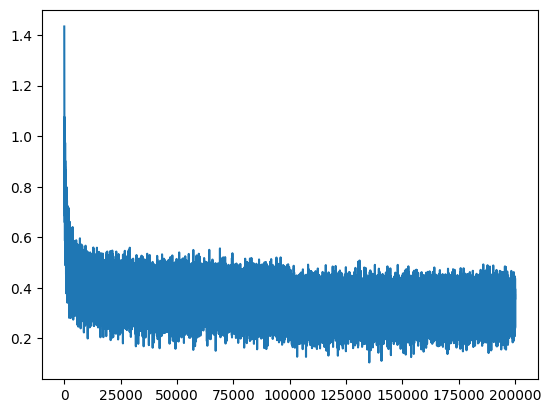

In [76]:
plt.plot(stepi, lossi)

In [77]:
# training loss
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1190, grad_fn=<NllLossBackward0>)

In [78]:
# validation loss
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1619, grad_fn=<NllLossBackward0>)

In [79]:
# test loss
emb = C[Xte] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Yte)
loss

tensor(2.1659, grad_fn=<NllLossBackward0>)

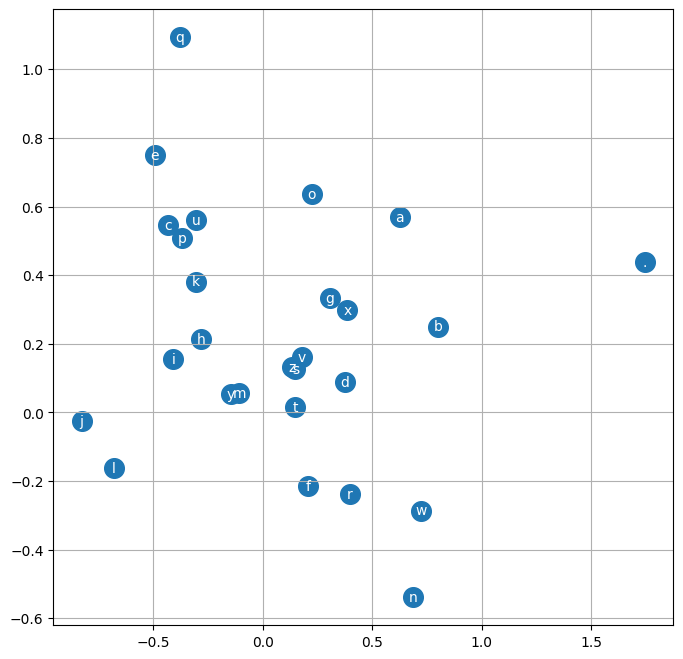

In [80]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [89]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])]
      #-1把后面两维与w1对齐了
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      #对logits每一行softmax
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))
print(logits.shape)

carmah.
amorie.
khy.
milia.
atlanna.
san.
jazone.
faverynciereni.
nellara.
chaiiv.
kaleigh.
ham.
joce.
quinthonor.
kalian.
quinte.
ogiearynn.
jaxen.
durah.
eddeci.
torch.Size([1, 27])
